# DDPM 基础：去噪扩散概率模型

> **难度：** 入门 | **时间：** 约 45 分钟

扩散模型（Diffusion Model）驱动了 Stable Diffusion、DALL-E、Imagen、Sora 以及当今大多数图像和视频生成器。它的核心思想出人意料地简单：先往数据里不断加噪声把它「毁掉」，再训练一个神经网络学会「倒放」这个过程。本 notebook 将从零开始帮你建立对这一思想的直觉理解——不需要任何扩散模型的先验知识。

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from mp_tutorial.diffusion import (
    linear_beta_schedule, cosine_beta_schedule, compute_alpha_bars, compute_snr,
    q_sample, SimpleDenoiser, make_swiss_roll,
    train_diffusion_2d_batched, ddpm_sample_loop,
)
from mp_tutorial.diffusion_viz import (
    draw_denoising_trajectory, draw_noise_schedule_comparison,
    draw_forward_process, draw_training_curves,
)
from mp_tutorial.formatting import info_box
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)

---
## 1. 什么是扩散模型？

**想象你往水里缓缓搅入墨汁。** 一开始你能看到清晰的色彩旋涡。继续搅拌，墨汁越扩越开。最终整杯水变成均匀的灰色——所有结构都消失了。

现在想象学会把它「搅回去」：给定那杯均匀的灰水，恢复出最初的墨汁图案。这就是扩散模型所做的事情，只不过「搅拌」变成了添加高斯噪声，而「逆搅拌」是一个训练好的神经网络。

整个过程分两半：
1. **「前向过程」（Forward Process，固定的）：** 逐步往数据里加噪声，直到它变成纯随机噪声。
2. **「逆向过程」（Reverse Process，学习的）：** 从噪声出发，一步步去除噪声来恢复数据。

我们先用一个简单的二维数据集来直观感受一下。

In [2]:
info_box(
    "<b>核心术语</b><br><br>"
    "<b>扩散模型（Diffusion Model）：</b>一种生成模型，通过学习逆转一个逐步加噪的过程来生成数据。"
    "名字来源于物理学中的扩散现象——粒子从高浓度区域向低浓度区域扩散。<br><br>"
    "<b>前向过程 q：</b>一个固定的（非学习的）过程，在 T 个时间步内逐步往数据中添加高斯噪声，"
    "最终将任何数据点变成纯噪声。<br><br>"
    "<b>逆向过程 p：</b>一个学习得到的过程，从纯噪声出发，每次去除一小步噪声，"
    "最终生成一个逼真的数据样本。",
    title="扩散模型术语表"
)

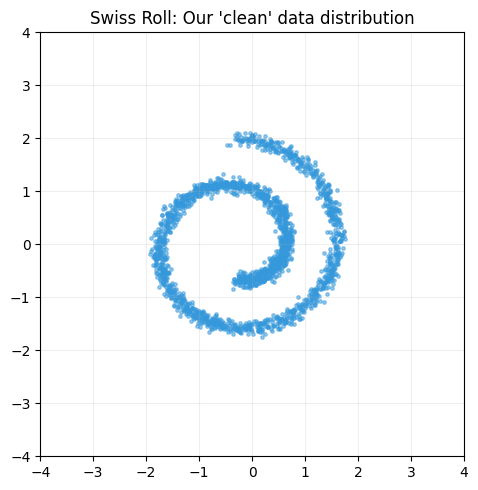

Data shape: torch.Size([2000, 2])  (2000 points in 2D)
This is our 'real' data distribution. The diffusion model will learn to generate new points that follow this shape.


In [3]:
# Generate 2D Swiss-roll data -- a curved distribution that is easy to visualise
torch.manual_seed(42)
data = make_swiss_roll(n_points=2000, seed=42)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), s=6, alpha=0.5, c="#3498db")
ax.set_title("Swiss Roll: Our 'clean' data distribution", fontsize=12)
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect("equal")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Data shape: {data.shape}  (2000 points in 2D)")
print(f"This is our 'real' data distribution. The diffusion model will learn to generate new points that follow this shape.")

---
## 2. 前向过程 $q(x_t | x_0)$

前向过程在 $T$ 个时间步内逐步往数据中添加高斯噪声。在每一步 $t$，我们将当前数据与一小部分噪声混合，噪声量由方差参数 $\beta_t$ 控制。

精妙之处在于：由于每一步都是高斯分布，我们可以**直接跳到**任意时间步 $t$，无需模拟中间步骤：

$$q(x_t | x_0) = \mathcal{N}\big(x_t;\; \sqrt{\bar\alpha_t}\, x_0,\; (1 - \bar\alpha_t)\, I\big)$$

等价地，我们可以直接采样 $x_t$：

$$x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1 - \bar\alpha_t}\, \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

### 这些符号是什么意思？

在进入代码之前，先用大白话解释每个量：

| 符号 | 名称 | 通俗解释 |
|--------|------|---------------|
| $\beta_t$ | **Beta** | 第 $t$ 步添加的噪声方差。值越小，加噪越轻柔。 |
| $\alpha_t = 1 - \beta_t$ | **Alpha** | 经过一步后，上一步信号的存活比例。 |
| $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$ | **Alpha-bar** | 经过 $t$ 步累积后，*原始*信号的存活比例。开始时接近 1，结束时接近 0。 |

当 $\bar\alpha_t \approx 1$ 时，数据几乎没有被加噪。当 $\bar\alpha_t \approx 0$ 时，数据已经和纯高斯噪声无法区分了。

In [4]:
# Set up the noise schedule
T = 1000  # total diffusion timesteps (standard for DDPM)
betas = linear_beta_schedule(T)
alpha_bars = compute_alpha_bars(betas)

# Print alpha_bar values at key timesteps
print("Alpha-bar values at selected timesteps:")
print(f"{'t':>6} | {'alpha_bar':>10} | {'signal weight':>14} | {'noise weight':>13}")
print("-" * 52)
for t_val in [0, 50, 100, 200, 500, 999]:
    ab = alpha_bars[t_val].item()
    print(f"{t_val:>6} | {ab:>10.6f} | {math.sqrt(ab):>14.4f} | {math.sqrt(1 - ab):>13.4f}")

print(f"\nAt t=0, the data is nearly clean (alpha_bar ~ 1).")
print(f"At t=999, the data is almost pure noise (alpha_bar ~ 0).")

Alpha-bar values at selected timesteps:
     t |  alpha_bar |  signal weight |  noise weight
----------------------------------------------------
     0 |   0.999900 |         0.9999 |        0.0100
    50 |   0.969951 |         0.9849 |        0.1733
   100 |   0.895141 |         0.9461 |        0.3238
   200 |   0.656347 |         0.8102 |        0.5862
   500 |   0.077797 |         0.2789 |        0.9603
   999 |   0.000040 |         0.0064 |        1.0000

At t=0, the data is nearly clean (alpha_bar ~ 1).
At t=999, the data is almost pure noise (alpha_bar ~ 0).


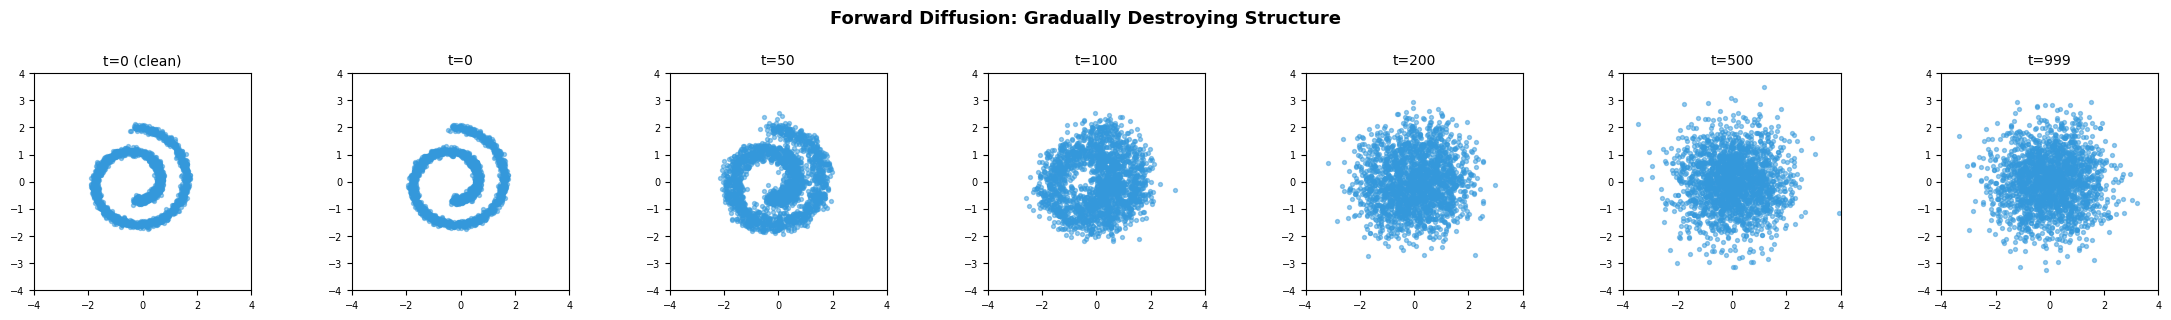

Left to right: the Swiss roll dissolves into noise.
The forward process is not learned -- it is pure math.
The model's job is to learn the reverse: noise -> Swiss roll.


In [5]:
# Visualise the forward process at t = 0, 50, 100, 200, 500, 999
fig, axes = draw_forward_process(
    data, alpha_bars,
    timesteps=[0, 50, 100, 200, 500, 999],
    title="Forward Diffusion: Gradually Destroying Structure"
)
plt.show()

print("Left to right: the Swiss roll dissolves into noise.")
print("The forward process is not learned -- it is pure math.")
print("The model's job is to learn the reverse: noise -> Swiss roll.")

注意结构是如何逐步消失的：
- 在 **t=0** 时数据是完好的。
- 在 **t=100** 时螺旋形变模糊了，但还能辨认。
- 在 **t=500** 时大部分结构已经消失。
- 在 **t=999** 时数据点和随机高斯噪声已经无法区分。

扩散模型的关键洞察：如果我们能学会逆转每一小步加噪过程，就可以把这些逆转串联起来，从纯噪声一路回到真实数据。

---
## 3. 噪声调度（Noise Schedule）

**「噪声调度」（Noise Schedule）** 就是 $\beta_t$ 值的序列，它控制了每个时间步加噪的强度。这是一个设计选择，对生成质量影响很大。

两种常见调度方式：

- **线性调度**（Ho et al., 2020）：$\beta_t$ 从一个小值线性增长到一个较大值。简单直接，但在早期时间步破坏信息的速度太快。
- **余弦调度**（Nichol & Dhariwal, 2021）：$\bar\alpha_t$ 沿余弦曲线下降，使信号的破坏更均匀地分布在所有时间步上。

比较调度方式的一个好指标是**信噪比（SNR）**：

$$\text{SNR}_t = \frac{\bar\alpha_t}{1 - \bar\alpha_t}$$

SNR 高意味着主要是信号；SNR 低意味着主要是噪声。好的调度方式应该让模型在*每个*时间步都有有意义的去噪工作可做，而不只是在噪声最大的那端。

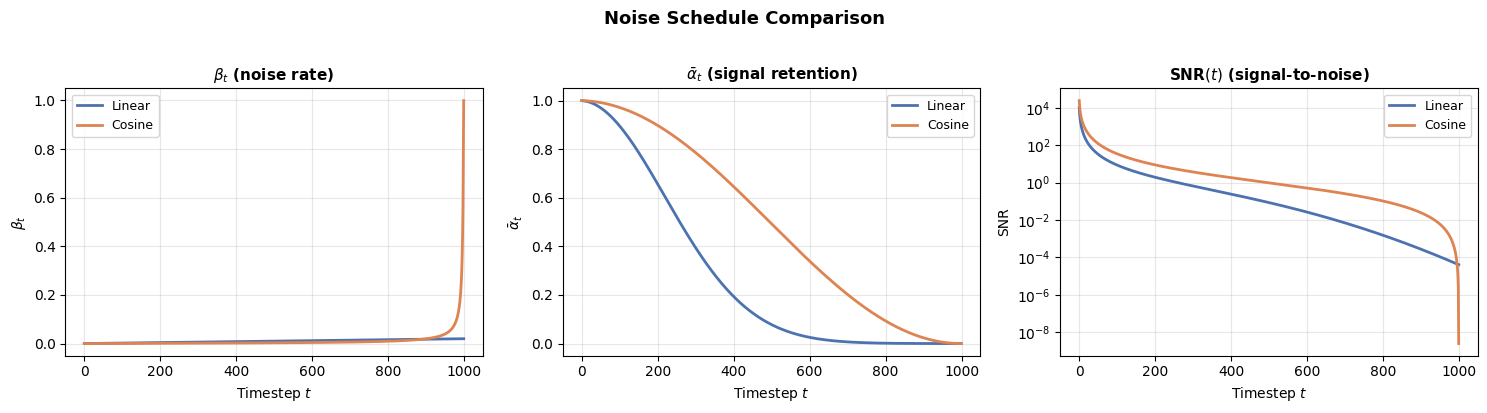

In [6]:
# Compare linear and cosine schedules
T_compare = 1000

betas_linear = linear_beta_schedule(T_compare)
betas_cosine = cosine_beta_schedule(T_compare)

schedules = {
    "Linear": betas_linear,
    "Cosine": betas_cosine,
}

fig, axes = draw_noise_schedule_comparison(schedules, T_compare)
plt.show()

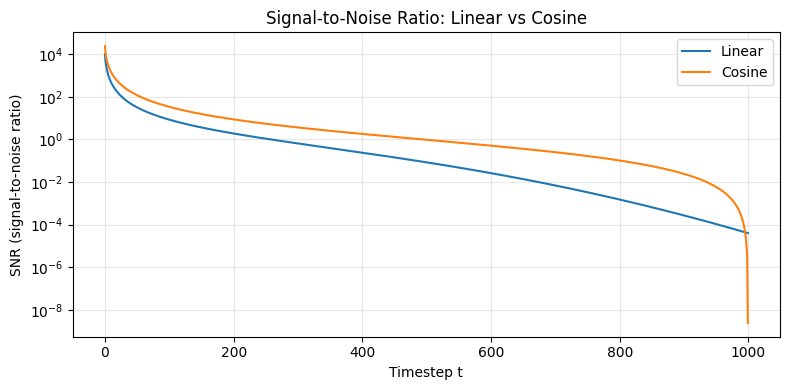

On a log scale, cosine SNR decreases more gradually.
Linear SNR crashes to near-zero quickly, wasting many early timesteps.


In [7]:
# Compare SNR curves
snr_linear = compute_snr(compute_alpha_bars(betas_linear))
snr_cosine = compute_snr(compute_alpha_bars(betas_cosine))

fig, ax = plt.subplots(figsize=(8, 4))
ts = np.arange(T_compare)
ax.plot(ts, snr_linear.numpy(), label="Linear", linewidth=1.5)
ax.plot(ts, snr_cosine.numpy(), label="Cosine", linewidth=1.5)
ax.set_xlabel("Timestep t")
ax.set_ylabel("SNR (signal-to-noise ratio)")
ax.set_title("Signal-to-Noise Ratio: Linear vs Cosine", fontsize=12)
ax.set_yscale("log")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print("On a log scale, cosine SNR decreases more gradually.")
print("Linear SNR crashes to near-zero quickly, wasting many early timesteps.")

In [8]:
info_box(
    "<b>余弦调度</b>在早期时间步保留了更多信号，让模型在整个 t 范围内都有有意义的去噪工作。"
    "而线性调度下，前 ~30% 的时间步图像几乎是干净的，模型可以轻松去噪，浪费了模型容量。"
    "余弦调度由 Nichol &amp; Dhariwal (2021) 提出，在实践中能带来明显更好的生成质量。",
    title="余弦调度：为什么重要"
)

---
## 4. 逆向过程与训练目标

现在来回答关键问题：**神经网络到底在学什么？**

### 先建立直觉

给定一个带噪声的样本 $x_t$ 和时间步 $t$，模型预测的是被添加的**噪声** $\epsilon$。如果它能准确预测噪声，我们就可以把噪声减掉来恢复出更干净的数据。

为什么预测噪声而不是直接预测干净数据？两者在数学上是等价的（可以用前向过程的公式互相转换），但预测噪声在数值上更稳定，也更容易训练。

### 简化版损失函数

训练流程简单得令人惊讶：

1. 从训练集中采样一个干净数据点 $x_0$
2. 随机采样一个时间步 $t \sim \text{Uniform}\{0, \ldots, T-1\}$
3. 采样噪声 $\epsilon \sim \mathcal{N}(0, I)$
4. 计算加噪版本：$x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1 - \bar\alpha_t}\, \epsilon$
5. 让模型预测噪声：$\hat\epsilon = \epsilon_\theta(x_t, t)$
6. 计算损失：$L = \|\epsilon - \hat\epsilon\|^2$

用公式表示：

$$L = \mathbb{E}_{t, x_0, \epsilon}\left[\|\epsilon - \epsilon_\theta(x_t, t)\|^2\right]$$

就这么简单。整个训练目标就是真实噪声和预测噪声之间的均方误差（MSE）。

In [9]:
info_box(
    "<b>为什么预测噪声有效？</b><br><br>"
    "由前向过程可知：$x_t = \\sqrt{\\bar\\alpha_t}\\, x_0 + \\sqrt{1 - \\bar\\alpha_t}\\, \\epsilon$<br><br>"
    "如果我们知道 $\\epsilon$，就可以反推出 $x_0$：<br>"
    "$x_0 = \\frac{x_t - \\sqrt{1 - \\bar\\alpha_t}\\, \\epsilon}{\\sqrt{\\bar\\alpha_t}}$<br><br>"
    "所以预测噪声和预测干净数据是<i>等价的</i>。无论哪种参数化方式，模型都隐式地学到了数据分布。"
    "Ho et al. (2020) 发现噪声预测这种参数化方式在实践中训练更稳定。",
    title="噪声预测 = 数据预测"
)

In [10]:
# Step-by-step demonstration of one training iteration
T_train = 200  # smaller T for fast CPU training
betas_train = linear_beta_schedule(T_train)
alpha_bars_train = compute_alpha_bars(betas_train)

# Create a tiny denoiser
model = SimpleDenoiser(data_dim=2, hidden=128, n_classes=1)

# Walk through one training step
torch.manual_seed(0)
batch = data[:64]                                         # 1. Sample clean data
t = torch.randint(0, T_train, (64,))                      # 2. Sample random timesteps
x_t, noise = q_sample(batch, t, alpha_bars_train)          # 3. Add noise
pred_noise = model(x_t, t)                                 # 4. Predict noise
loss = F.mse_loss(pred_noise, noise)                       # 5. Compute MSE

print("One training step, broken down:")
print(f"  1. Batch of clean data:   {tuple(batch.shape)}")
print(f"  2. Random timesteps:      {t[:8].tolist()} ...")
print(f"  3. Noisy x_t:             {tuple(x_t.shape)}")
print(f"  4. Predicted noise:       {tuple(pred_noise.shape)}")
print(f"  5. MSE loss:              {loss.item():.4f}")
print(f"\nAt initialisation the model outputs random values, so loss is ~ 1.0.")
print(f"After training it should drop well below that.")

One training step, broken down:
  1. Batch of clean data:   (64, 2)
  2. Random timesteps:      [44, 39, 133, 160, 163, 179, 27, 103] ...
  3. Noisy x_t:             (64, 2)
  4. Predicted noise:       (64, 2)
  5. MSE loss:              0.8536

At initialisation the model outputs random values, so loss is ~ 1.0.
After training it should drop well below that.


In [11]:
# Train the model on Swiss-roll data (T=200, ~200 epochs, fast on CPU)
torch.manual_seed(42)
model = SimpleDenoiser(data_dim=2, hidden=128, n_classes=1)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")
print(f"Timesteps: {T_train}")
print(f"Training on {len(data)} Swiss-roll points for 200 epochs...\n")

losses = train_diffusion_2d_batched(
    model, data, betas_train, alpha_bars_train,
    n_epochs=200, batch_size=256, lr=3e-4, seed=42
)

print(f"\nFinal loss: {losses[-1]:.6f}")

Model parameters: 41,922
Timesteps: 200
Training on 2000 Swiss-roll points for 200 epochs...



  Epoch   50/200 | Loss: 0.615563


  Epoch  100/200 | Loss: 0.605103


  Epoch  150/200 | Loss: 0.597331


  Epoch  200/200 | Loss: 0.560099

Final loss: 0.560099


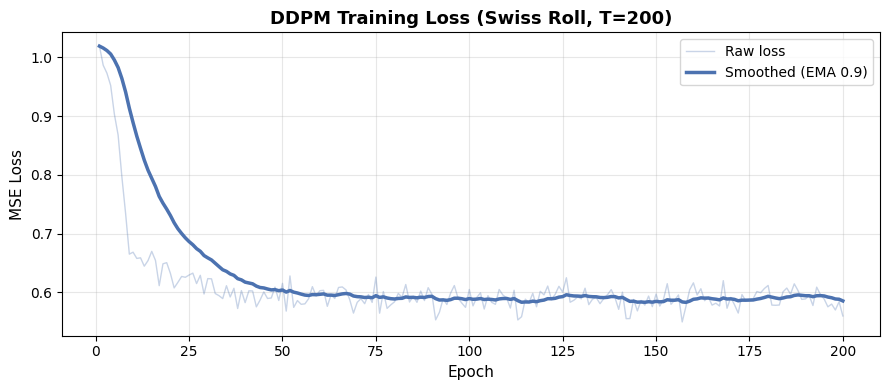

Loss dropped from 1.0190 to 0.5601 (1.8x reduction).
The model learned to predict noise accurately across all timesteps.


In [12]:
# Plot the training loss curve
fig, ax = draw_training_curves(losses, title="DDPM Training Loss (Swiss Roll, T=200)")
plt.show()

print(f"Loss dropped from {losses[0]:.4f} to {losses[-1]:.4f} "
      f"({losses[0]/losses[-1]:.1f}x reduction).")
print(f"The model learned to predict noise accurately across all timesteps.")

---
## 5. 采样（逆向去噪）

现在到了最激动人心的部分：通过运行逆向过程来**生成新数据**。

### DDPM 采样算法

从纯高斯噪声 $x_T \sim \mathcal{N}(0, I)$ 出发，我们逆向遍历每个时间步：

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{\beta_t}{\sqrt{1 - \bar\alpha_t}}\, \epsilon_\theta(x_t, t) \right) + \sigma_t\, z$$

其中当 $t > 0$ 时 $z \sim \mathcal{N}(0, I)$，当 $t = 0$ 时 $z = 0$，且 $\sigma_t = \sqrt{\beta_t}$。

**用大白话说**，每一步做三件事：
1. **问模型** $x_t$ 里的噪声 $\epsilon$ 是多少
2. **减去**一个缩放后的预测噪声（部分去噪）
3. **加入**少量新的随机噪声（最后一步除外）

第 3 步的新噪声对样本多样性至关重要。没有它，所有样本最终都会收敛到同一个点。

In [13]:
# Generate samples using DDPM sampling, recording the trajectory
torch.manual_seed(123)
model.eval()

samples, trajectory = ddpm_sample_loop(
    model, betas_train, alpha_bars_train,
    shape=(500, 2),
    record_every=25,  # capture a snapshot every 25 steps
)

print(f"Generated {samples.shape[0]} new samples")
print(f"Recorded {len(trajectory)} trajectory snapshots (from noise to data)")

Generated 500 new samples
Recorded 9 trajectory snapshots (from noise to data)


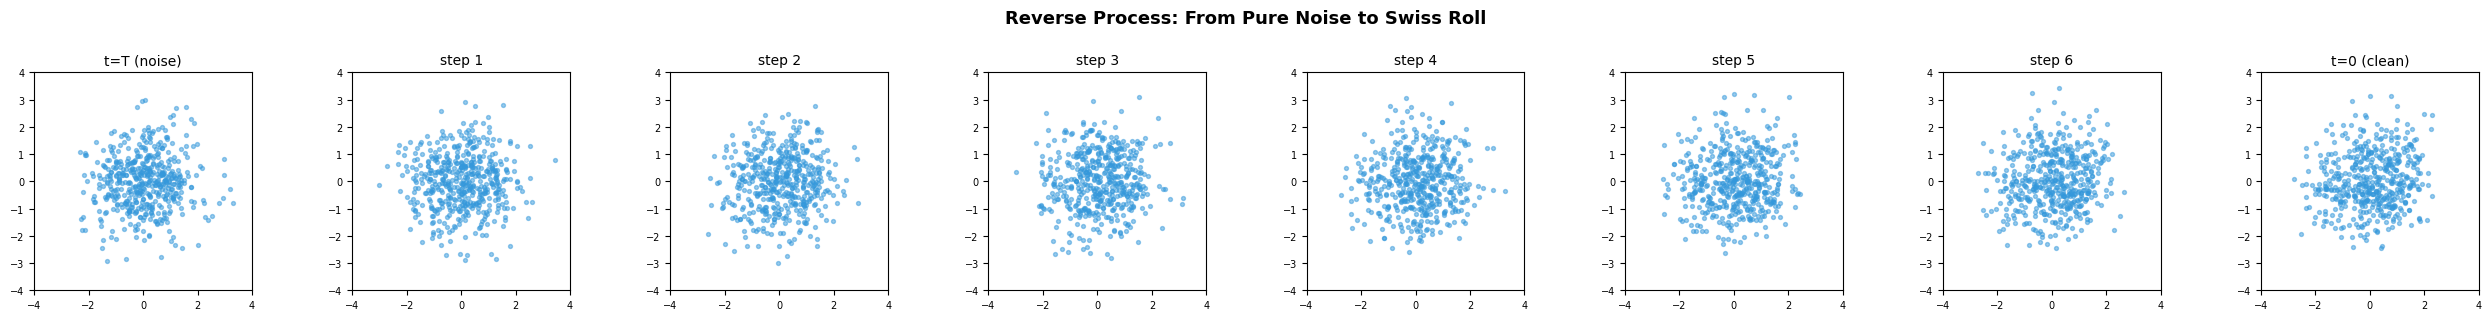

Each panel shows a snapshot of the 500 sample points.
The leftmost panel is pure noise; the rightmost is the final generated distribution.


In [14]:
# Visualise the denoising trajectory: noise -> data
fig, axes = draw_denoising_trajectory(
    trajectory,
    title="Reverse Process: From Pure Noise to Swiss Roll"
)
plt.show()

print("Each panel shows a snapshot of the 500 sample points.")
print("The leftmost panel is pure noise; the rightmost is the final generated distribution.")

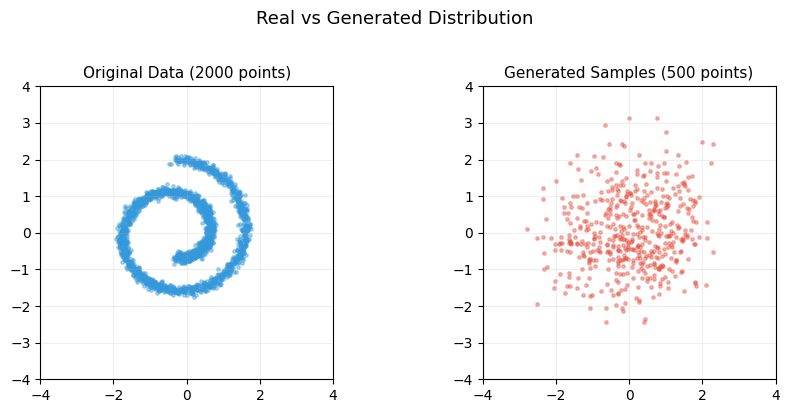

The generated samples follow the Swiss-roll shape!
These are NEW points sampled from the learned distribution -- not copies of training data.


In [15]:
# Side-by-side comparison: original data vs generated samples
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Original data
axes[0].scatter(data[:, 0].numpy(), data[:, 1].numpy(), s=6, alpha=0.4, c="#3498db")
axes[0].set_title("Original Data (2000 points)", fontsize=11)
axes[0].set_xlim(-4, 4); axes[0].set_ylim(-4, 4)
axes[0].set_aspect("equal")
axes[0].grid(alpha=0.2)

# Generated samples
samples_np = samples.detach().cpu().numpy()
axes[1].scatter(samples_np[:, 0], samples_np[:, 1], s=6, alpha=0.4, c="#e74c3c")
axes[1].set_title("Generated Samples (500 points)", fontsize=11)
axes[1].set_xlim(-4, 4); axes[1].set_ylim(-4, 4)
axes[1].set_aspect("equal")
axes[1].grid(alpha=0.2)

fig.suptitle("Real vs Generated Distribution", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

print("The generated samples follow the Swiss-roll shape!")
print("These are NEW points sampled from the learned distribution -- not copies of training data.")

---
## 6. 工程视角

### 速度：房间里的大象

DDPM 生成一个样本需要 **T 个顺序执行的去噪步骤**，每一步都是一次完整的神经网络前向传播。实际情况：

| 设置 | 步数 (T) | 每张图耗时 (A100) |
|---------|----------|----------------------|
| 我们的玩具示例 | 200 | 几乎瞬间（2D） |
| 原始 DDPM | 1000 | 约 20 秒（256x256） |
| 高分辨率生成 | 1000 | 数分钟（1024x1024） |

与 GAN（一次前向传播即可生成）不同，DDPM 用速度换取了训练稳定性和生成质量。

### T（时间步数）与质量、速度的权衡

更多的时间步意味着更精细的去噪增量和更好的质量，但采样速度也成比例地变慢。$T = 1000$ 是原始默认值；$T = 200$ 对于玩具数据已经足够。下一个 notebook 将展示如何用更少的步骤获得高质量生成。

In [16]:
info_box(
    "<b>什么样的训练曲线算'好'？</b><br><br>"
    "扩散模型的损失通常先快速下降，然后进入平台期并缓慢提升。"
    "这是正常的：模型先学会去噪简单的（低噪声）时间步，然后逐渐在更难的（高噪声）时间步上变好。<br><br>"
    "<b>危险信号：</b><br>"
    "- 损失从一开始就不动：模型没有在学习（检查学习率、数据加载）。<br>"
    "- 损失发散或出现尖峰：学习率太高或数值问题。<br>"
    "- 损失剧烈波动：batch size 可能太小。<br><br>"
    "<b>好消息：</b>与 GAN 不同，扩散模型很少出现模式坍塌（mode collapse），"
    "因为训练本质上是简单的回归（MSE），而不是对抗博弈。",
    title="如何看懂扩散模型的训练曲线"
)

In [17]:
info_box(
    "原始 DDPM 生成一个样本需要 <b>T = 1000 个逆向步骤</b>——对于生产环境来说太慢了。"
    "下一个 notebook "
    "<a href='01-sampling-acceleration.ipynb'>采样加速</a>，"
    "介绍了 DDIM、DPM-Solver 等方法，它们复用同一个训练好的模型，"
    "但只需 20-50 分之一的步数，质量损失极小。",
    title="下一步：更快的采样"
)

print("训练大型扩散模型（如 Stable Diffusion 的 UNet，约 8.6 亿参数）")
print("需要与 LLM 相同的分布式训练策略。")
print("参见张量并行：../../en/02-tensor-parallelism.ipynb")

训练大型扩散模型（如 Stable Diffusion 的 UNet，约 8.6 亿参数）
需要与 LLM 相同的分布式训练策略。
参见张量并行：../../en/02-tensor-parallelism.ipynb


---
## 7. 总结

### 核心概念

- **前向过程：** 固定的数学操作，在 $T$ 步内逐步添加高斯噪声，将任何数据变为纯噪声。
- **闭式采样：** $x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1-\bar\alpha_t}\, \epsilon$ 让我们可以直接跳到任意噪声水平，无需模拟中间步骤。
- **噪声调度：** 控制加噪速度。余弦调度 > 线性调度。
- **训练目标：** 真实噪声与预测噪声之间的简单 MSE：$L = \|\epsilon - \epsilon_\theta(x_t, t)\|^2$。
- **逆向过程（采样）：** 从 $x_T \sim \mathcal{N}(0,I)$ 开始，逐步去噪回到数据。
- **速度瓶颈：** 原始 DDPM 每生成一个样本需要 $T$ 次顺序前向传播。生产系统使用加速采样器。

### 延伸阅读

- Ho, Jain, Abbeel. *Denoising Diffusion Probabilistic Models* (2020). [arXiv:2006.11239](https://arxiv.org/abs/2006.11239)
- Nichol, Dhariwal. *Improved Denoising Diffusion Probabilistic Models* (2021). [arXiv:2102.09672](https://arxiv.org/abs/2102.09672)
- Sohl-Dickstein et al. *Deep Unsupervised Learning using Nonequilibrium Thermodynamics* (2015). [arXiv:1503.03585](https://arxiv.org/abs/1503.03585)

### 下一个 notebook

[01-sampling-acceleration.ipynb](01-sampling-acceleration.ipynb) -- DDIM、DPM-Solver，以及如何用 20-50 步（而非 1000 步）获得高质量样本。